In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
BASE_PATH = r"C:\Users\Thomas\Desktop\distributed\experiments\real"
ALGORITHMS = ["Cheap If Possible", "Greedy", "Threshold-Based Scheduler", "Uniform Progression Scheduler", "Intelligent Bidding"]
RUNS = range(48)  # 48 as there are 12 workloads for each algorithm

In [3]:
def calculate_total_price(task_file):
    
    df = pd.read_parquet(task_file)
    filtered_task_df = df[(df['price'] > 0) & (df['cpu_count'] > 0)] # remove invalid and calculate total price
    total_price = filtered_task_df['price'].sum()
    return total_price


In [4]:
def count_price_states(task_file):

    df = pd.read_parquet(task_file)

    #count occurences of each price state
    running_tasks = df[df['task_state'] == 'RUNNING']
    price_state_counts = running_tasks['price_state'].value_counts().to_dict()

    # add on demand and spot if they are not present
    price_state_counts = {
        'ON_DEMAND': price_state_counts.get('ON_DEMAND', 0),
        'SPOT': price_state_counts.get('SPOT', 0)
    }
    return price_state_counts


In [5]:
results = []
price_state_results = []

# calculate total task price for each run
for algorithm in ALGORITHMS:
    algorithm_path = os.path.join(BASE_PATH, algorithm)
    algorithm_results = {"Algorithm": algorithm, "Total_Prices": []}
    price_state_algorithm_results = {"Algorithm": algorithm, "Price_States": []}

    for run in RUNS:
        run_path = os.path.join(algorithm_path, "raw-output", str(run), "seed=0", "task.parquet")
        if os.path.exists(run_path):
            total_price = calculate_total_price(run_path)
            algorithm_results["Total_Prices"].append(total_price)

            price_state_counts = count_price_states(run_path) # count price states
            price_state_algorithm_results["Price_States"].append(price_state_counts)
            
        else:
            print(f"File not found: {run_path}")
            algorithm_results["Total_Prices"].append(0)  # add zero if the file is missing
            price_state_algorithm_results["Price_States"].append({"ON_DEMAND": 0, "SPOT": 0})

    results.append(algorithm_results)
    price_state_results.append(price_state_algorithm_results)

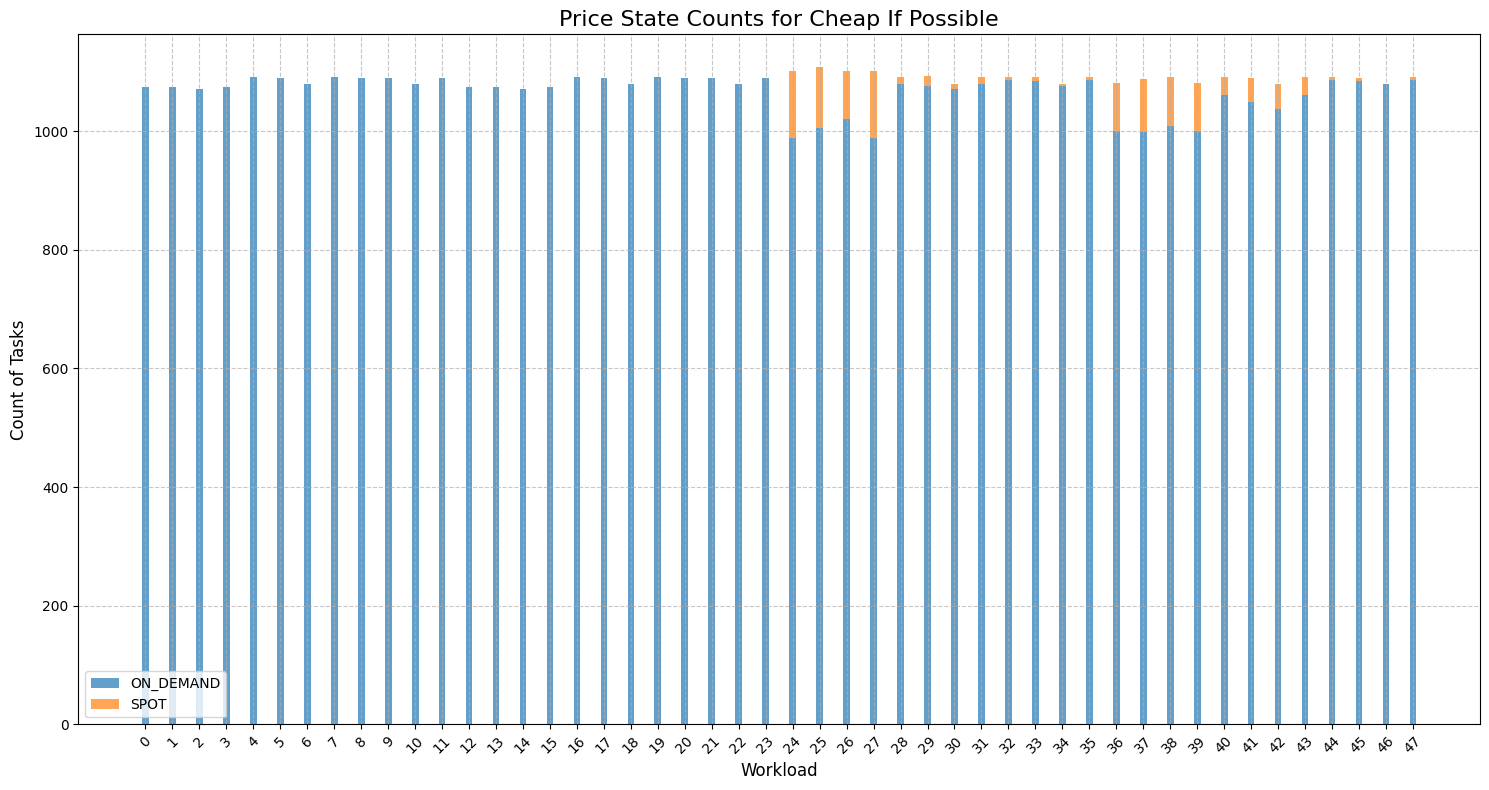

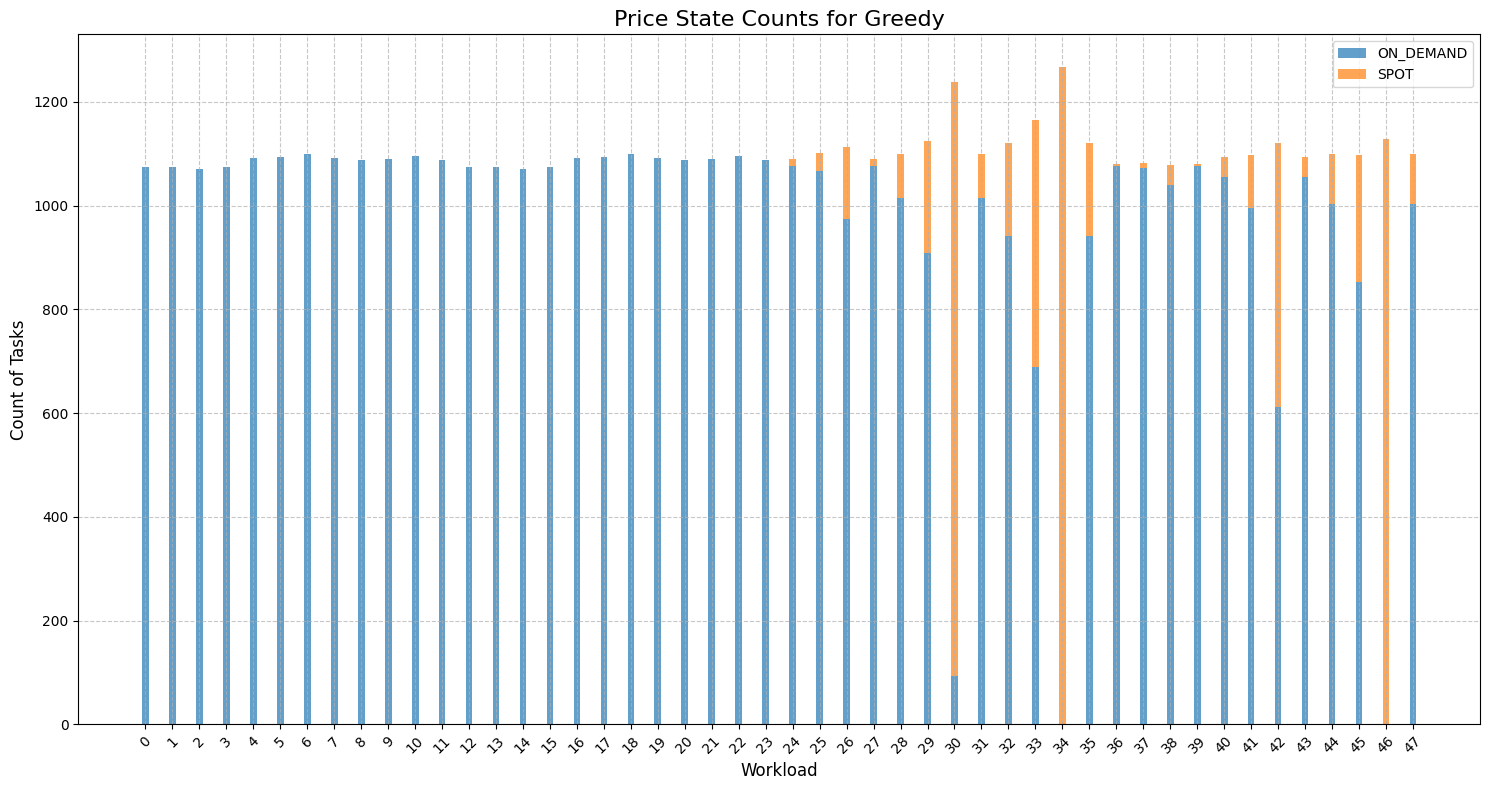

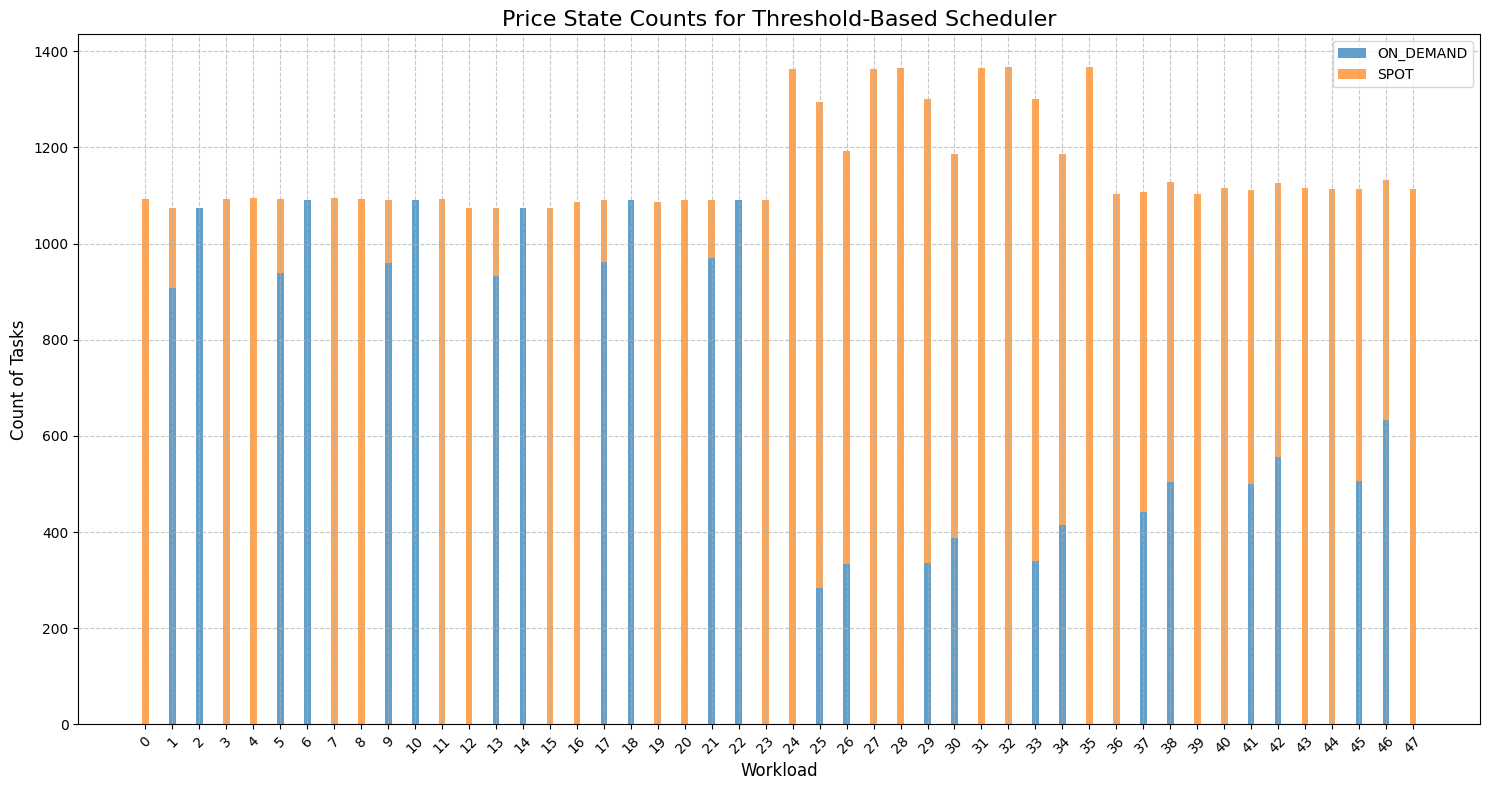

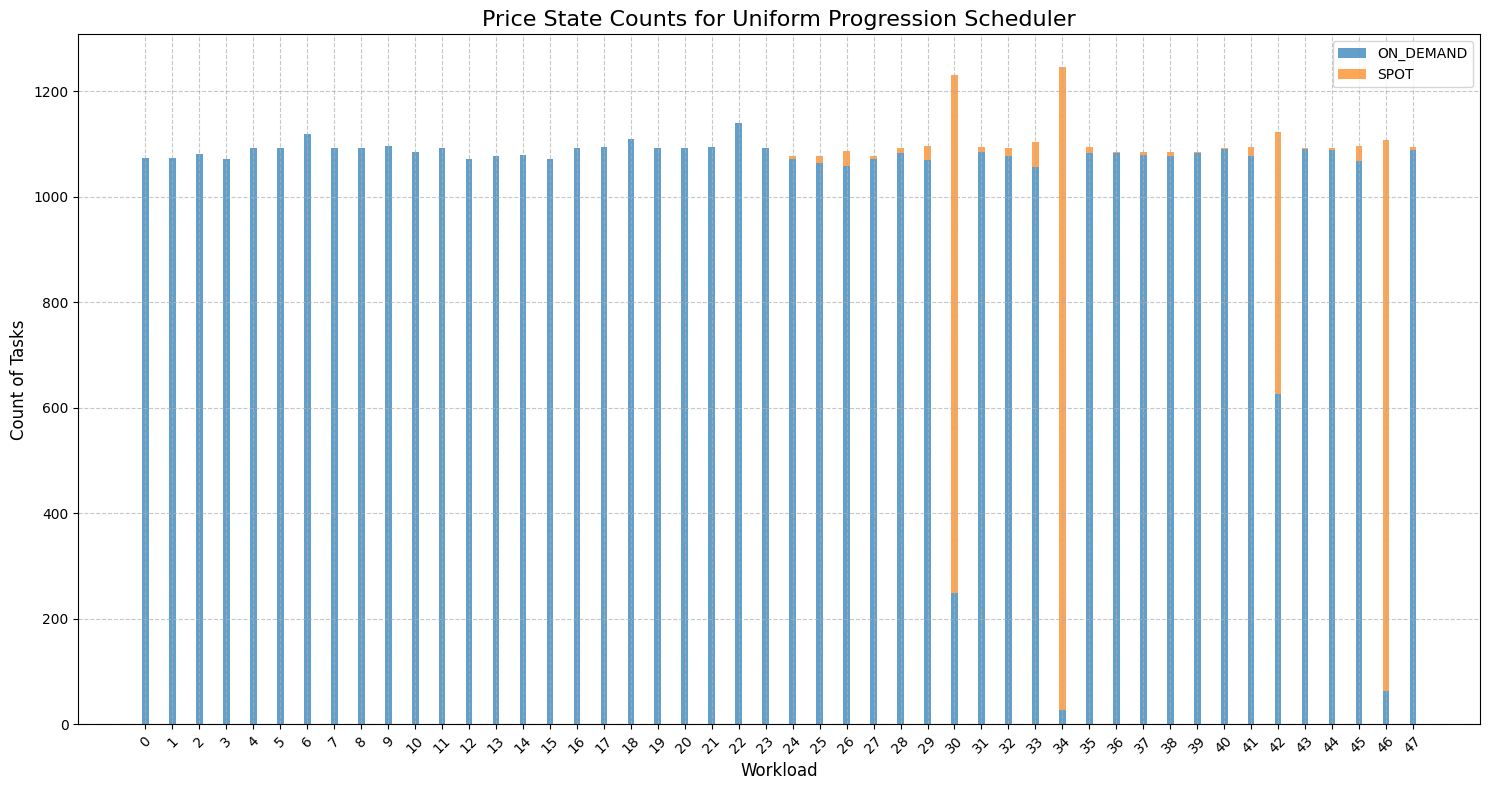

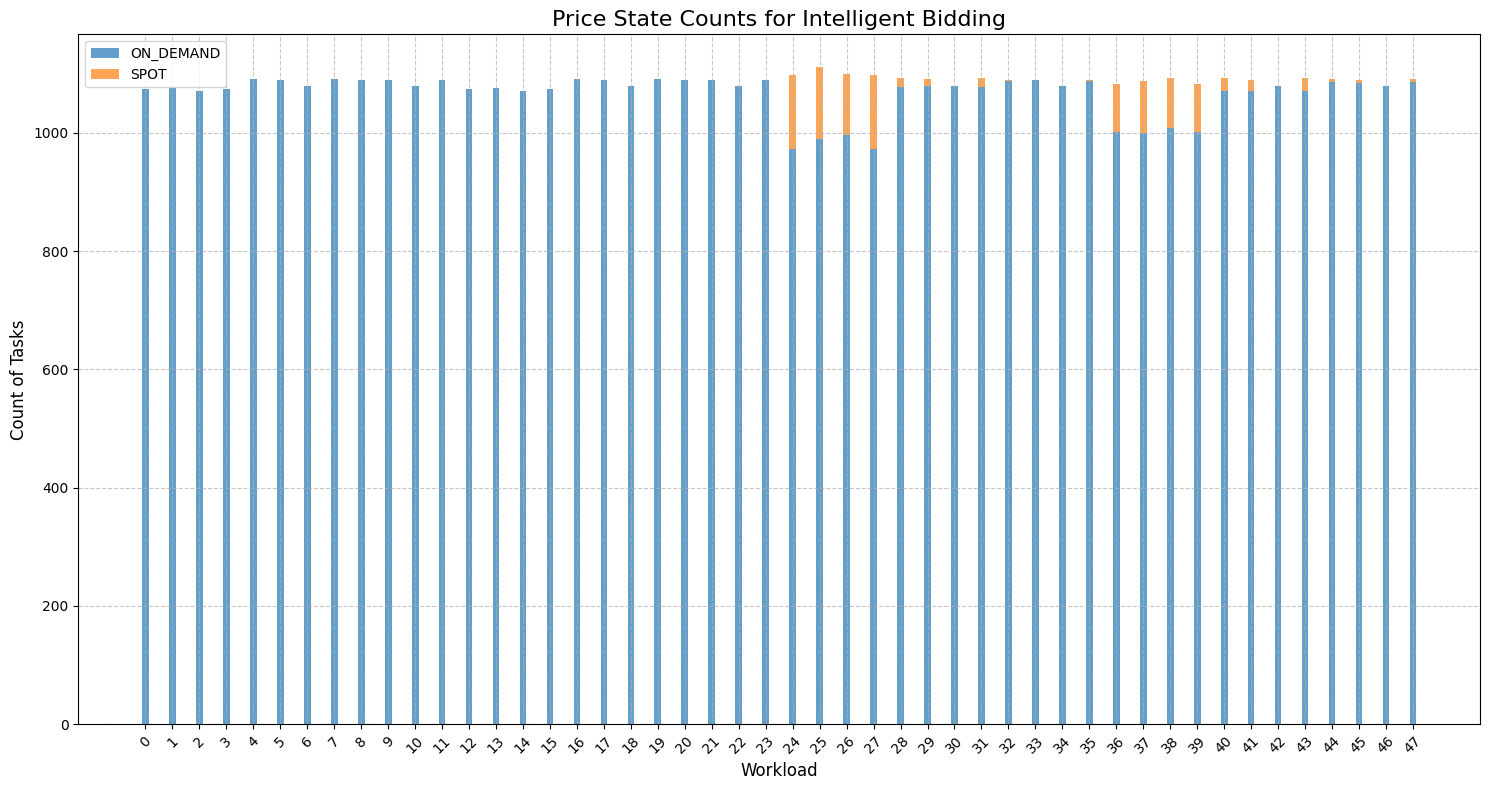

In [6]:
bar_width = 0.25
x_positions = range(len(RUNS))

for price_state_algorithm_results in price_state_results:
    algorithm = price_state_algorithm_results["Algorithm"]
    on_demand_counts = [state["ON_DEMAND"] for state in price_state_algorithm_results["Price_States"]]
    spot_counts = [state["SPOT"] for state in price_state_algorithm_results["Price_States"]]




    plt.figure(figsize=(15, 8))
    plt.bar(x_positions, on_demand_counts, bar_width, label="ON_DEMAND", alpha=0.7) # on demand
    plt.bar(x_positions, spot_counts, bar_width, bottom=on_demand_counts, label="SPOT", alpha=0.7) # spot on top
    plt.title(f"Price State Counts for {algorithm}", fontsize=16)
    plt.xlabel("Workload", fontsize=12)
    plt.ylabel("Count of Tasks", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(ticks=[x for x in x_positions], labels=RUNS, rotation=45)
    plt.tight_layout()
    plt.show()


good, but unclear. better to calculate as percentages

__The following is for graphs 4 - 8__


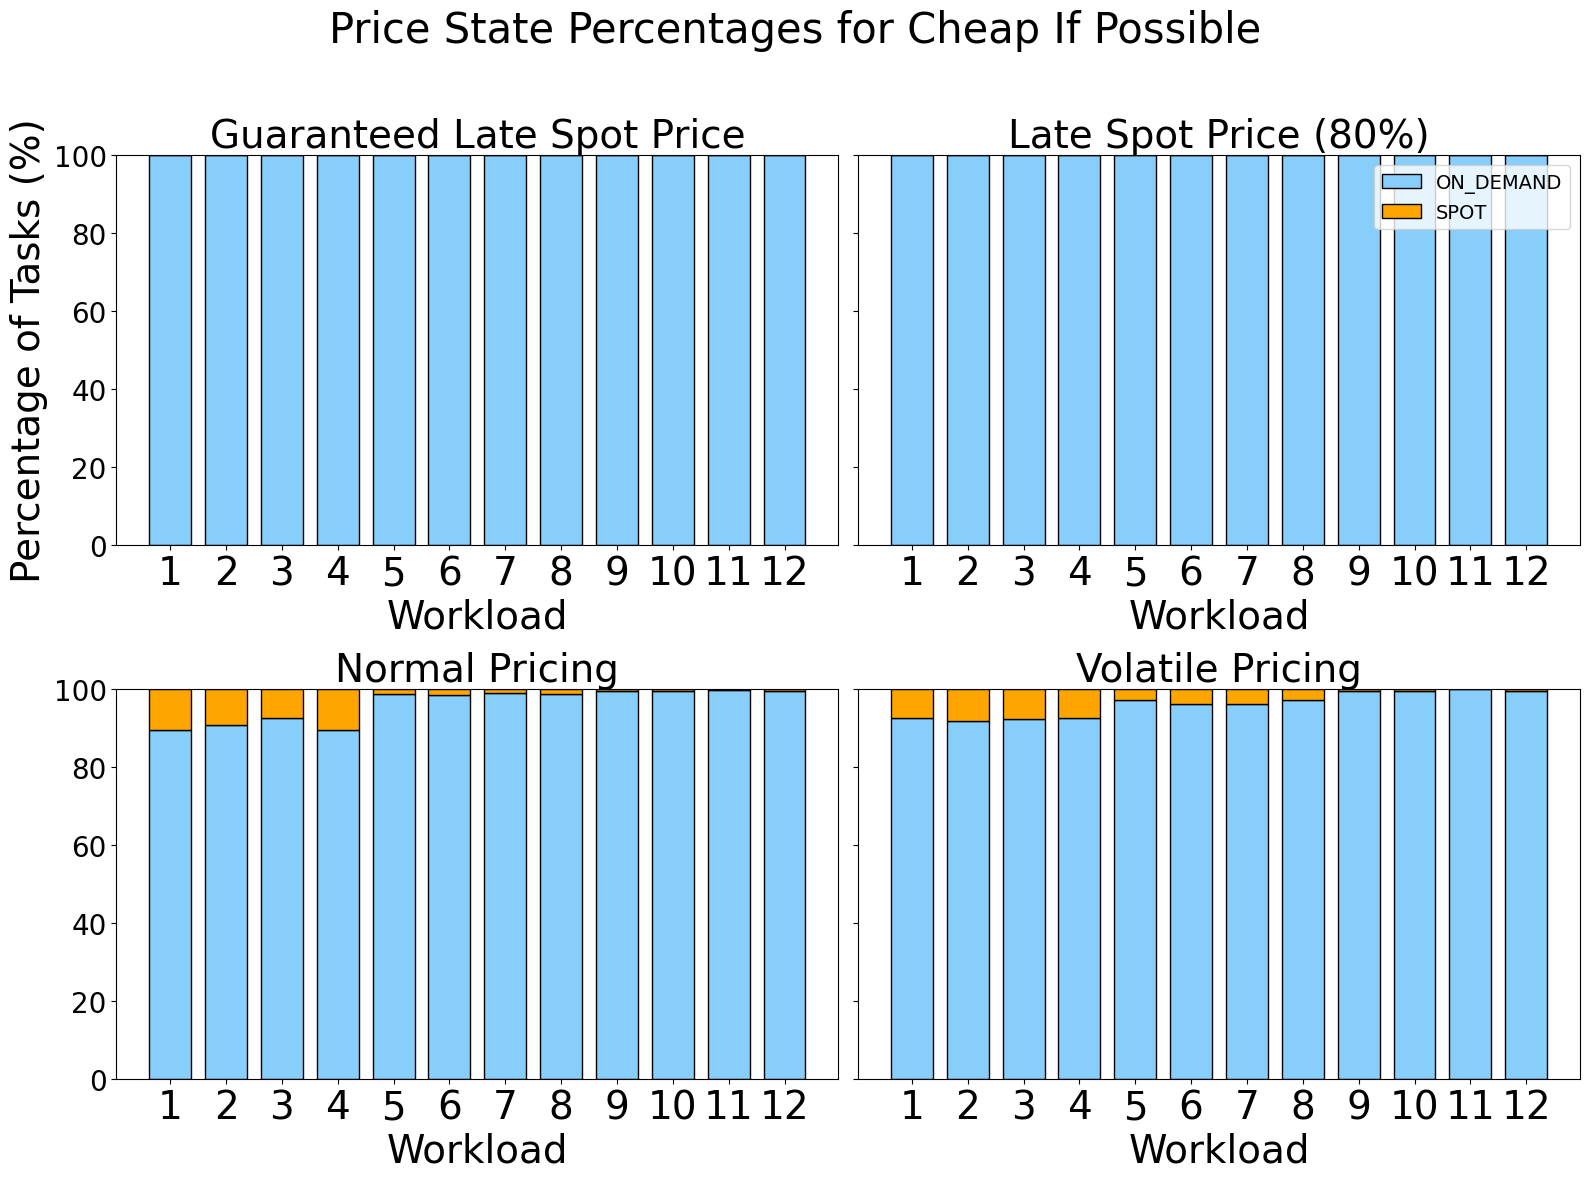

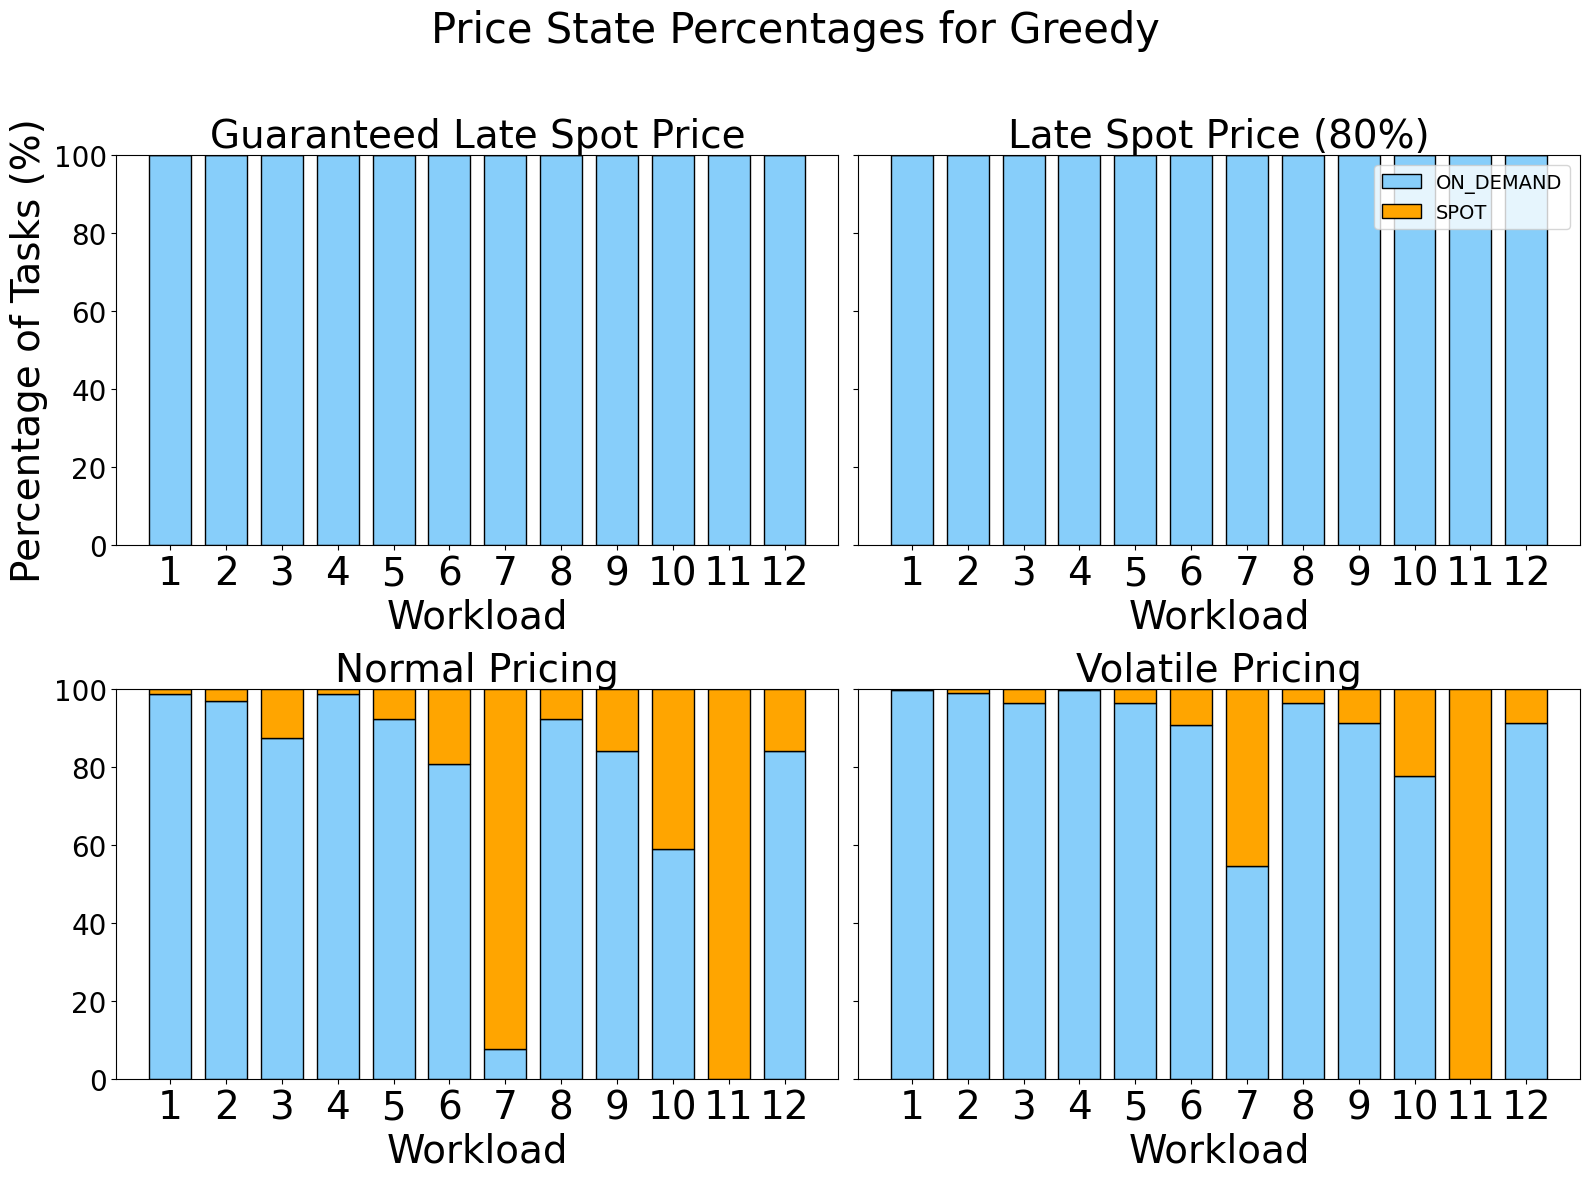

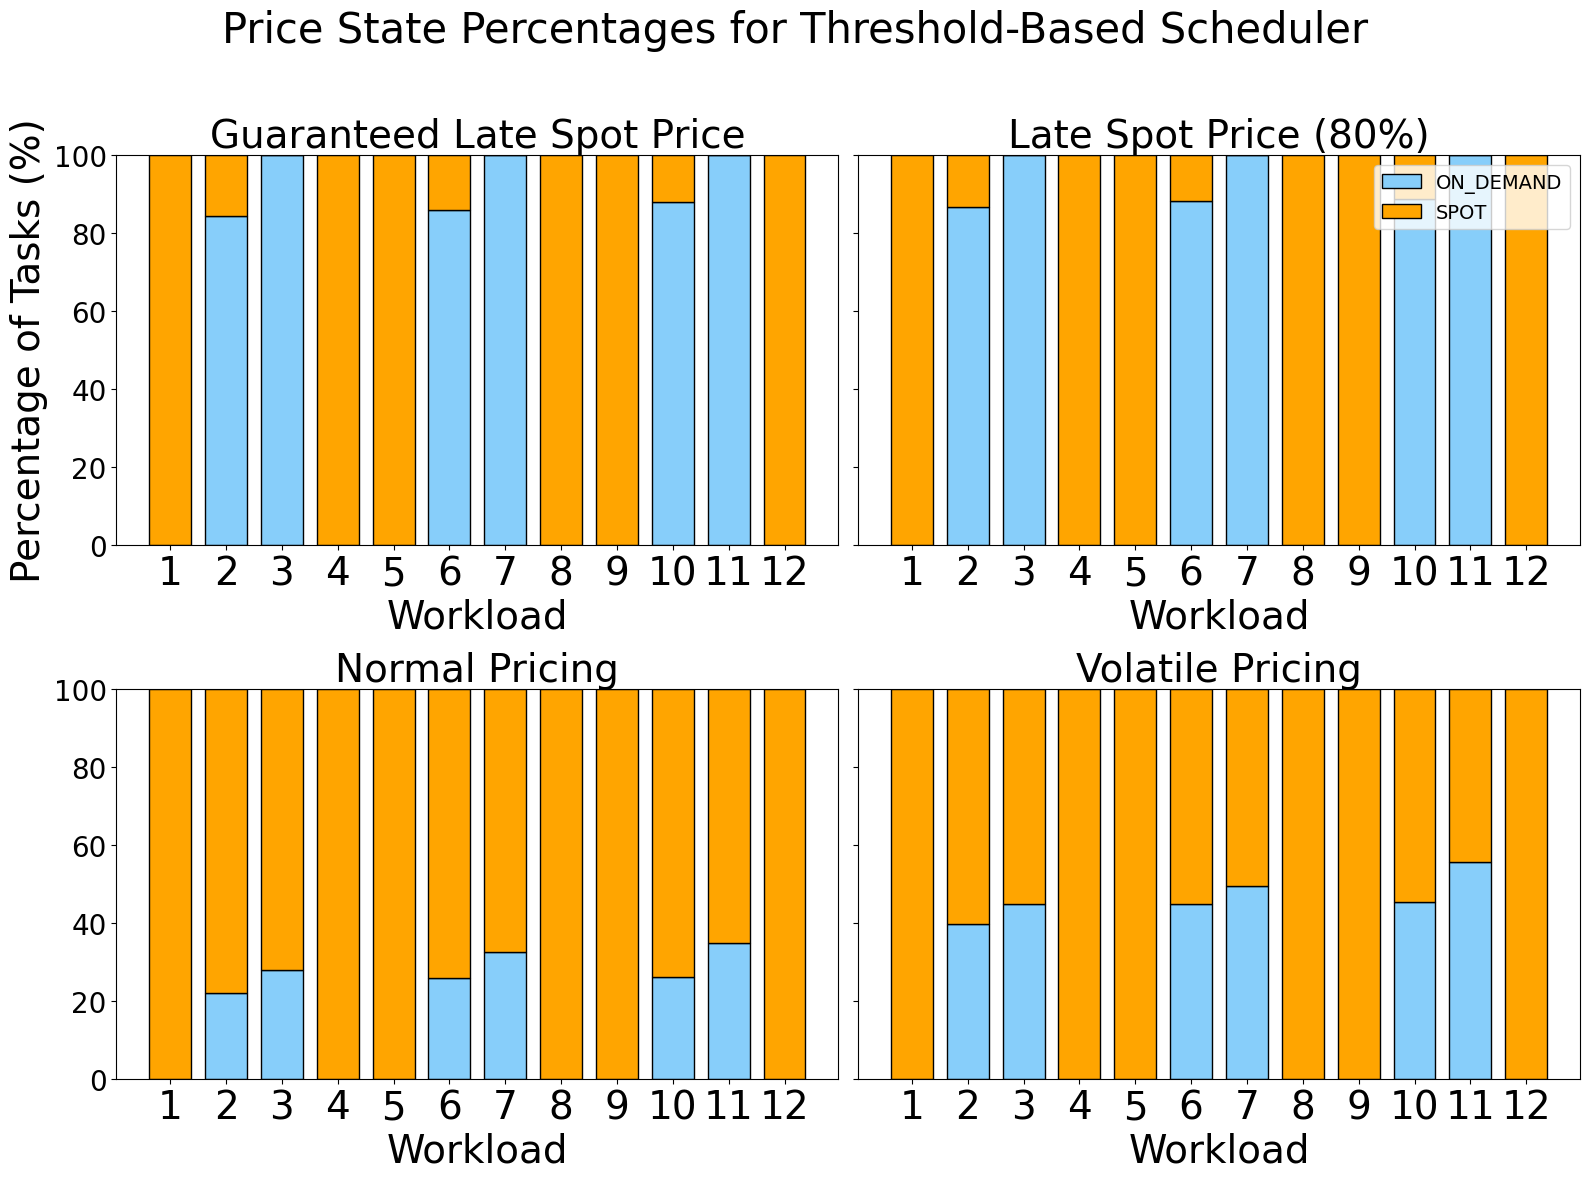

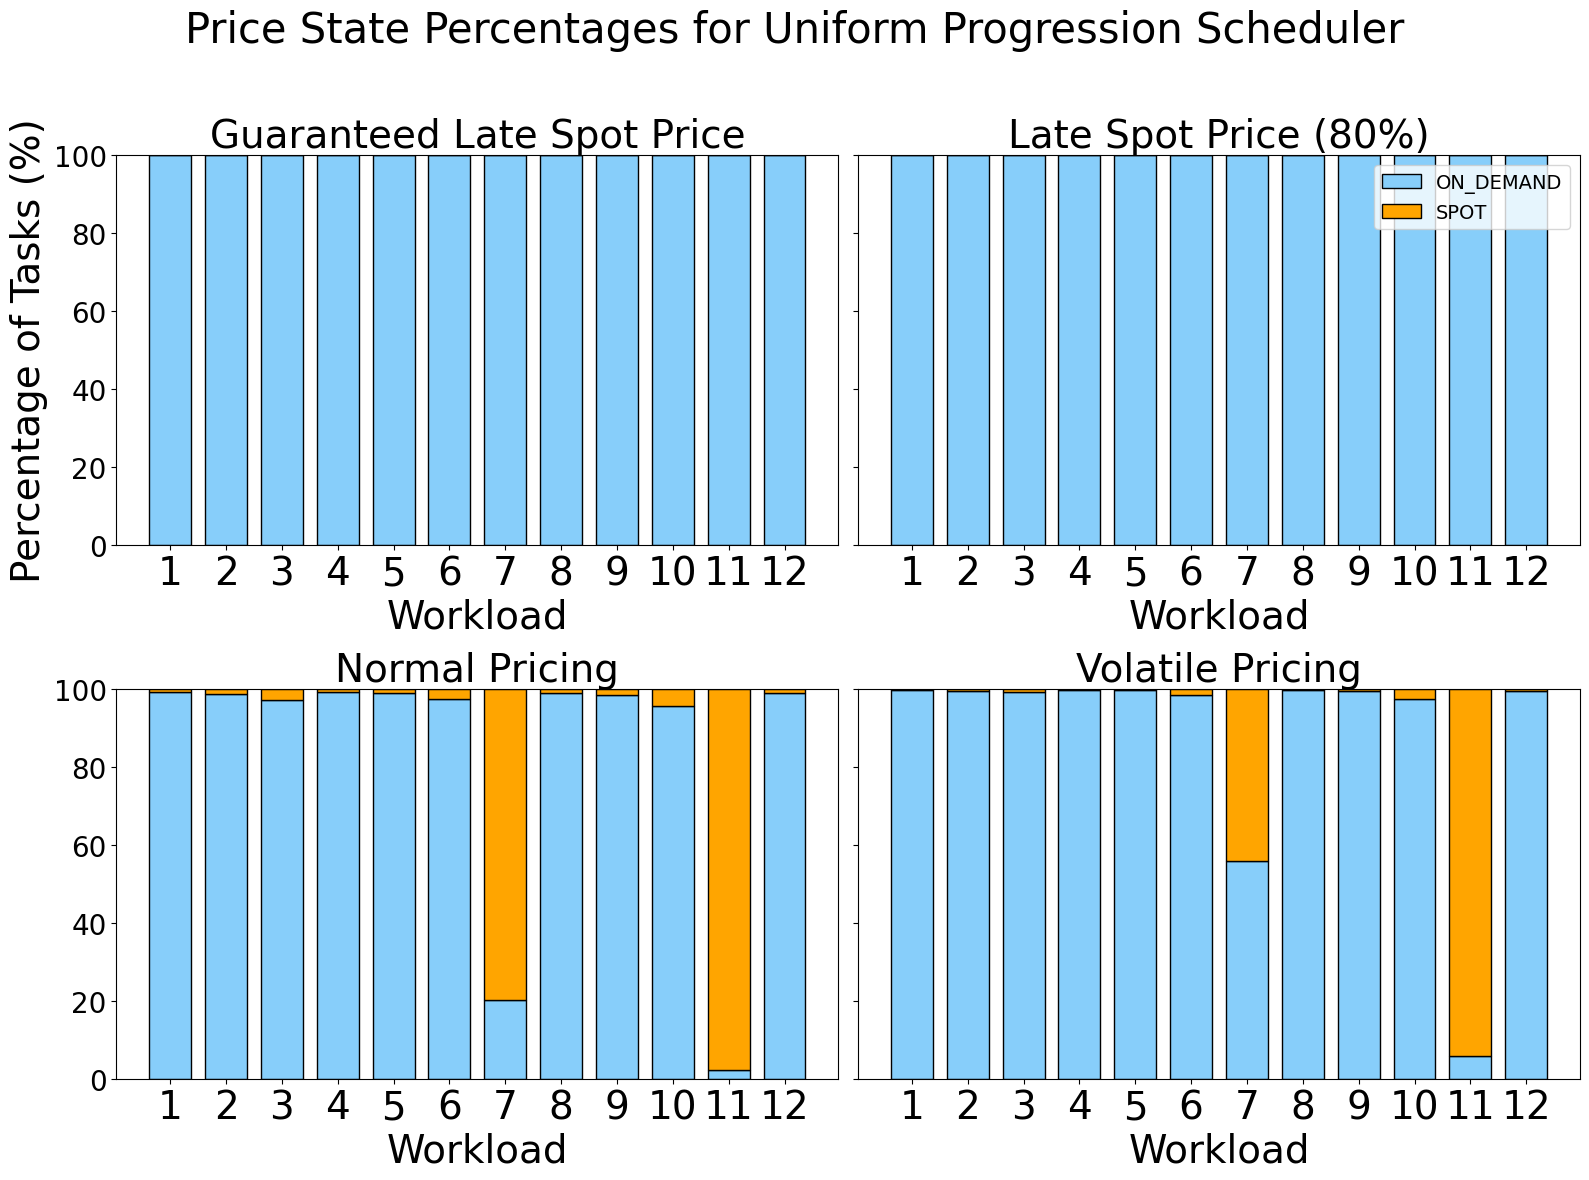

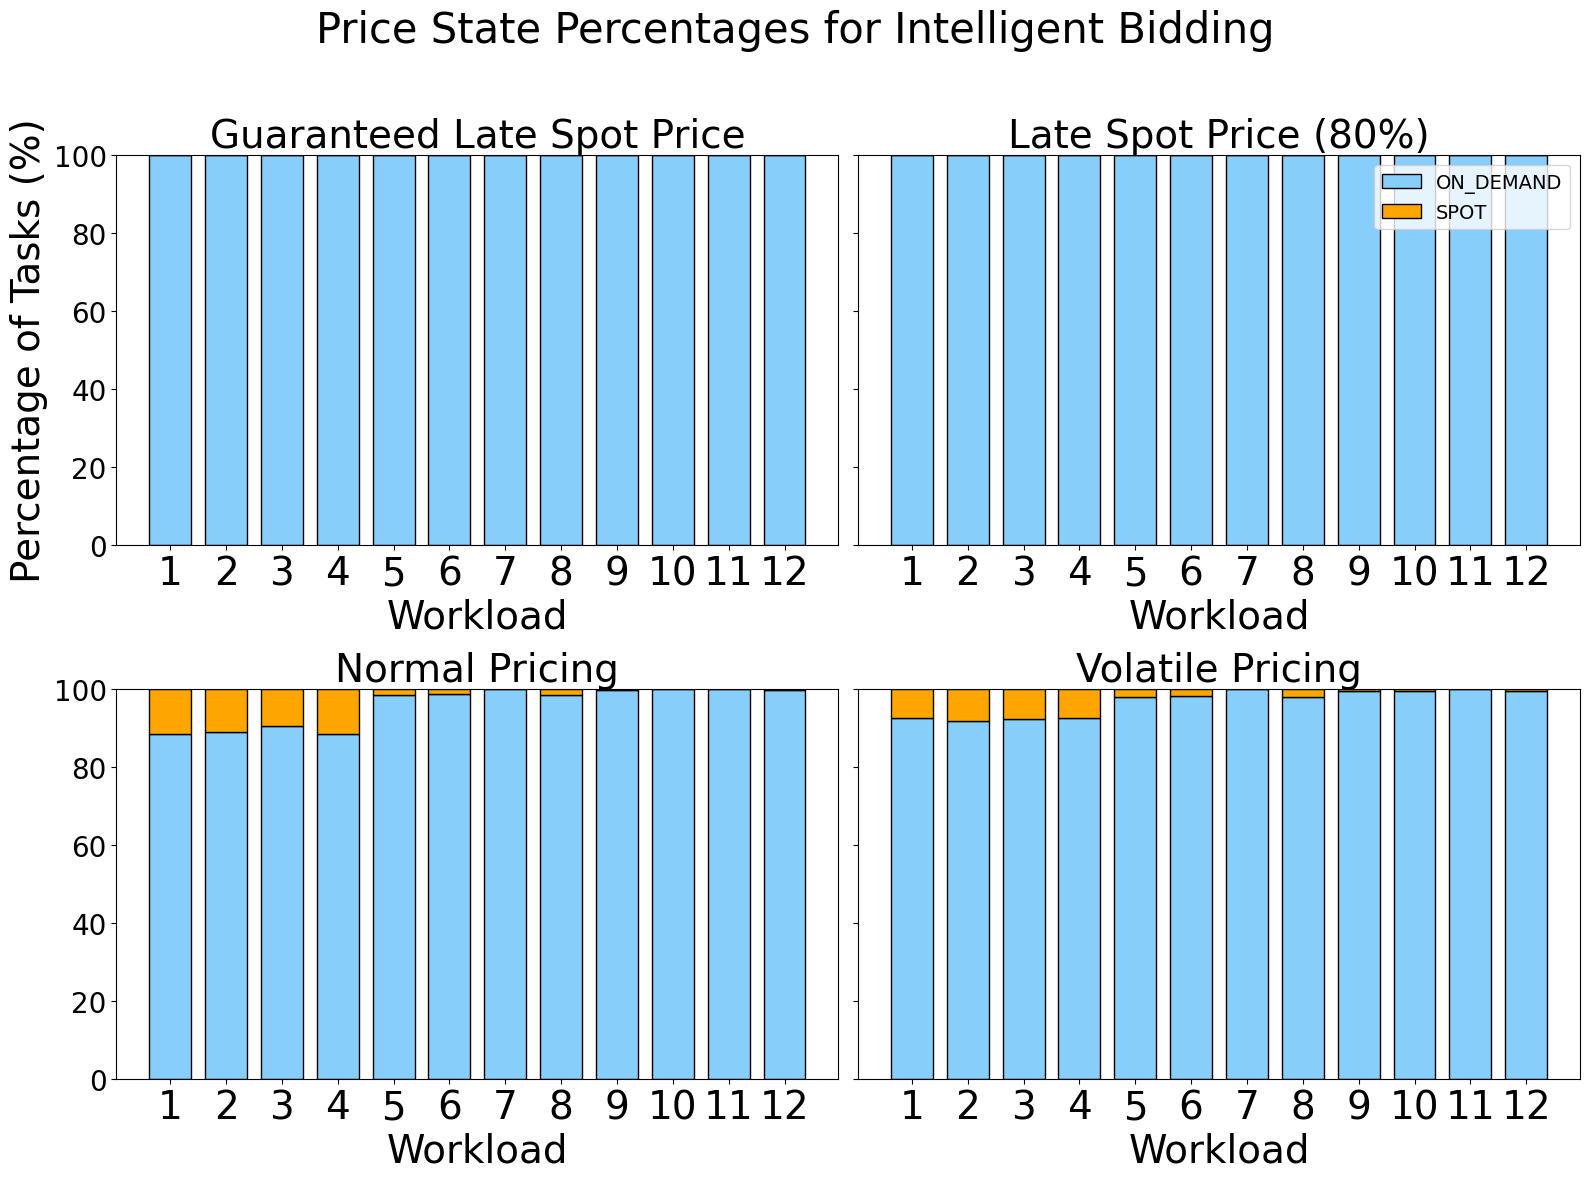

In [26]:
bar_width = 0.75
x_positions = range(12)  # 12 workloads for each algorithm
blue_rgba = (135 / 255, 206 / 255, 250 / 255, 1)  # sky Blue
orange_rgba = (255 / 255, 165 / 255, 0 / 255, 1)  # orange
sections = ["Guaranteed Late Spot Price", "Late Spot Price (80%)", "Normal Pricing", "Volatile Pricing"]

for price_state_algorithm_results in price_state_results:
    algorithm = price_state_algorithm_results["Algorithm"]
    on_demand_counts = [state["ON_DEMAND"] for state in price_state_algorithm_results["Price_States"]]
    spot_counts = [state["SPOT"] for state in price_state_algorithm_results["Price_States"]]

    # percentages
    total_counts = [on + spot for on, spot in zip(on_demand_counts, spot_counts)]
    on_demand_percentages = [on / total * 100 if total > 0 else 0 for on, total in zip(on_demand_counts, total_counts)]
    spot_percentages = [spot / total * 100 if total > 0 else 0 for spot, total in zip(spot_counts, total_counts)]

    # split into sections
    section_data = [
        (on_demand_percentages[i:i + 12], spot_percentages[i:i + 12]) 
        for i in range(0, len(on_demand_percentages), 12)
    ]
    fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharey=True)  # Keep the figure size the same
    axs = axs.flatten()  # Flatten to make it easier to iterate through

    for idx, (on_demand, spot) in enumerate(section_data):
        axs[idx].bar(
            x_positions,
            on_demand,
            bar_width,
            label="ON_DEMAND",
            color=blue_rgba,
            edgecolor='black'
        )
        axs[idx].bar(
            x_positions,
            spot,
            bar_width,
            bottom=on_demand,
            label="SPOT",
            color=orange_rgba,
            edgecolor='black'
        )
        axs[idx].set_title(sections[idx], fontsize=28)
        axs[idx].set_xlabel("Workload", fontsize=28)
        axs[idx].set_xticks(x_positions)
        axs[idx].set_xticklabels(range(1, 13), fontsize=28)
        axs[idx].tick_params(axis='y', labelsize=20)
        axs[idx].grid(False)

    axs[0].set_ylabel("Percentage of Tasks (%)", fontsize=28)
    axs[1].legend(loc="upper right", fontsize=14)
    fig.suptitle(f"Price State Percentages for {algorithm}", fontsize=30)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Padding to the top
    plt.show()


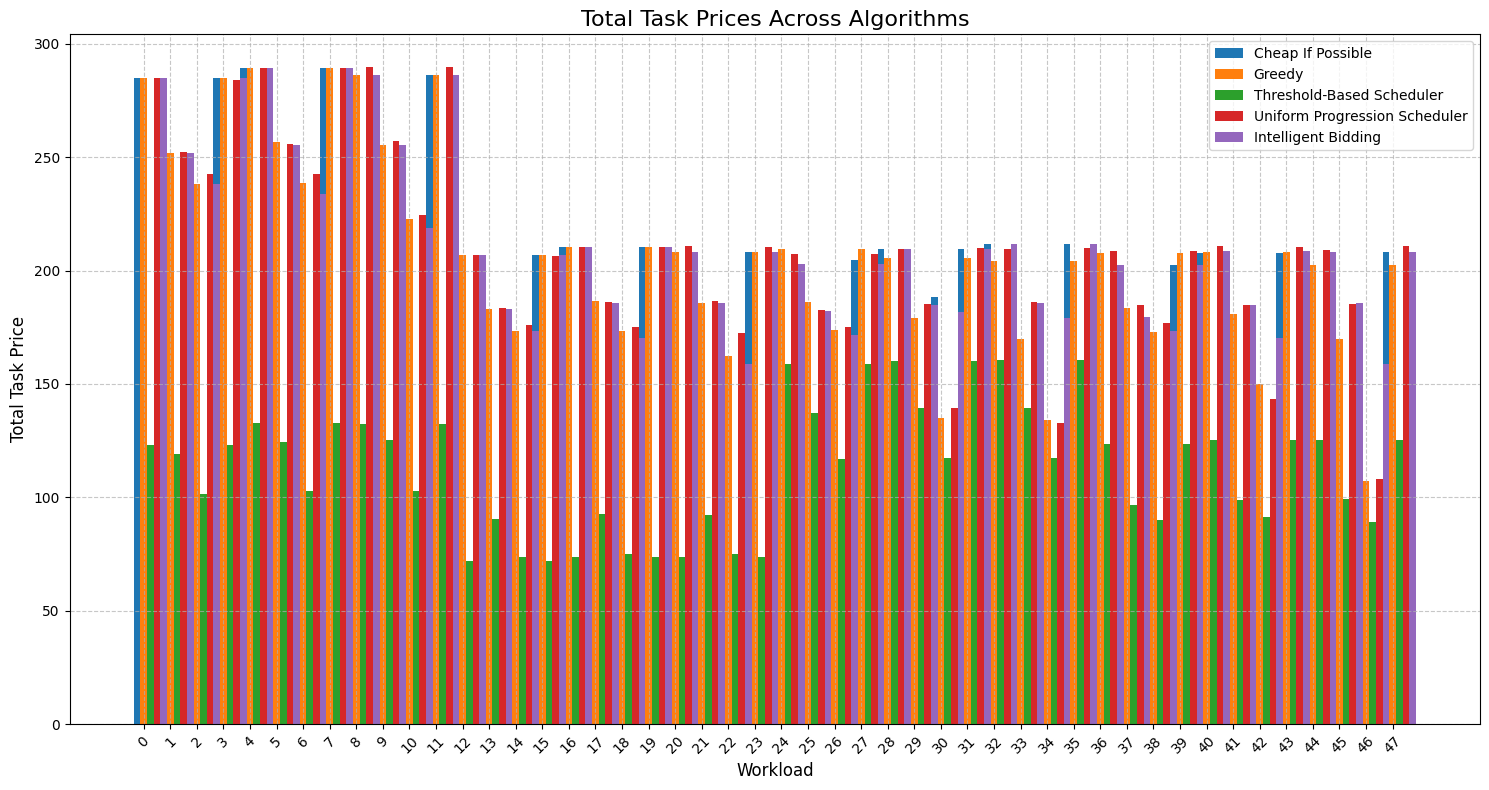

In [8]:
bar_width = 0.25
x_positions = range(len(RUNS))

plt.figure(figsize=(15, 8))
for i, algorithm_results in enumerate(results):
    plt.bar(
        [x + i * bar_width for x in x_positions], 
        algorithm_results["Total_Prices"], 
        width=bar_width, 
        label=algorithm_results["Algorithm"]
    )

plt.title("Total Task Prices Across Algorithms", fontsize=16)
plt.xlabel("Workload", fontsize=12)
plt.ylabel("Total Task Price", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=[x + bar_width for x in x_positions], labels=RUNS, rotation=45)
plt.tight_layout()
plt.show()

* looks promising, but data is stacked

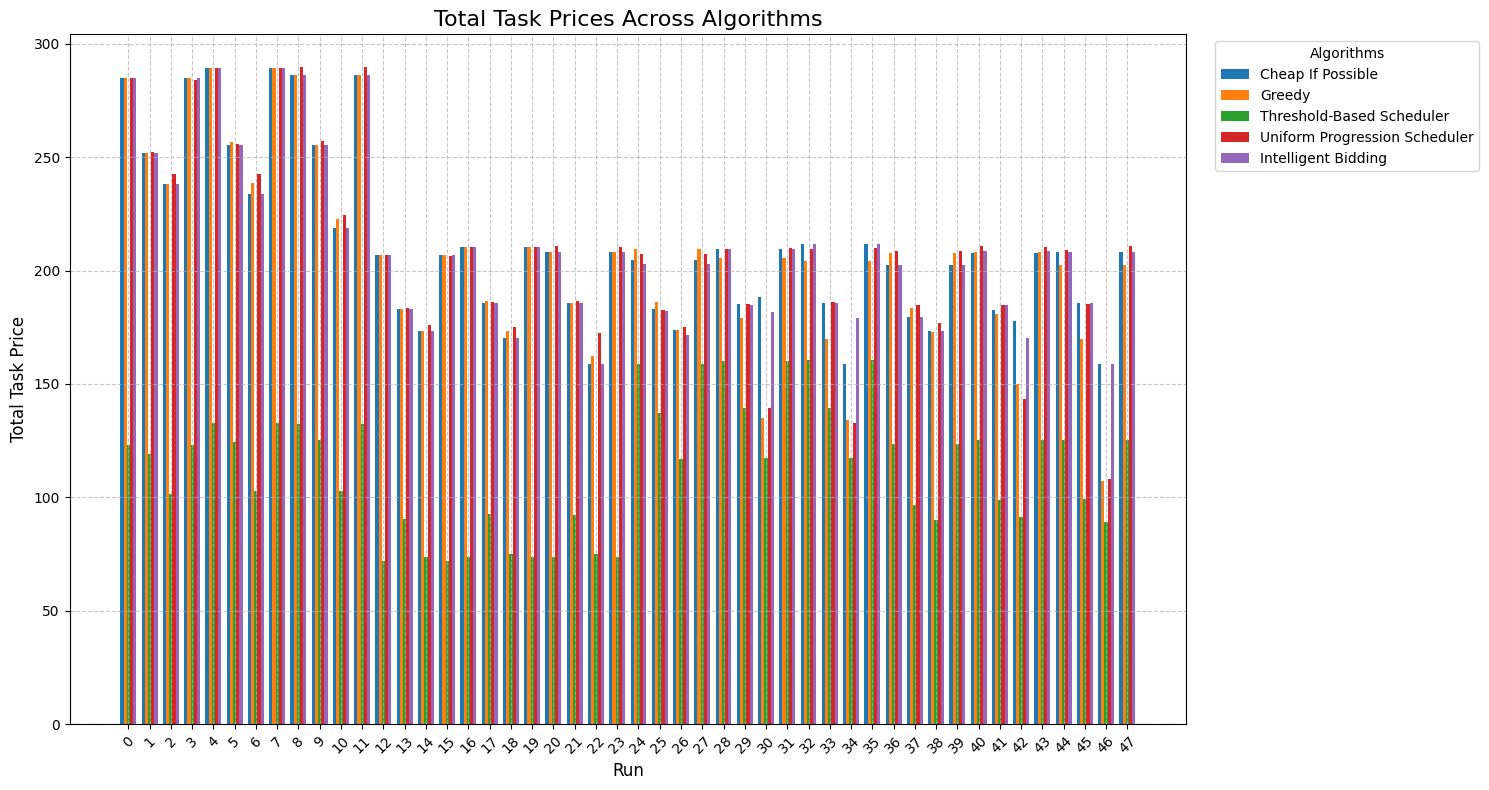

In [9]:
bar_width = 0.15
x_positions = range(len(RUNS))

plt.figure(figsize=(15, 8))

for i, algorithm_results in enumerate(results):
    plt.bar(
        [x + i * bar_width for x in x_positions], 
        algorithm_results["Total_Prices"],
        width=bar_width, 
        label=algorithm_results["Algorithm"]
    )

plt.title("Total Task Prices Across Algorithms", fontsize=16)
plt.xlabel("Run", fontsize=12)
plt.ylabel("Total Task Price", fontsize=12)
plt.legend(title="Algorithms", fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=[x + (bar_width * 2) for x in x_positions], labels=RUNS, rotation=45)
plt.tight_layout()
plt.show()


unreadable. we should split the data into the 4 different price traces for clarity



__The following code is for Figure 2:__

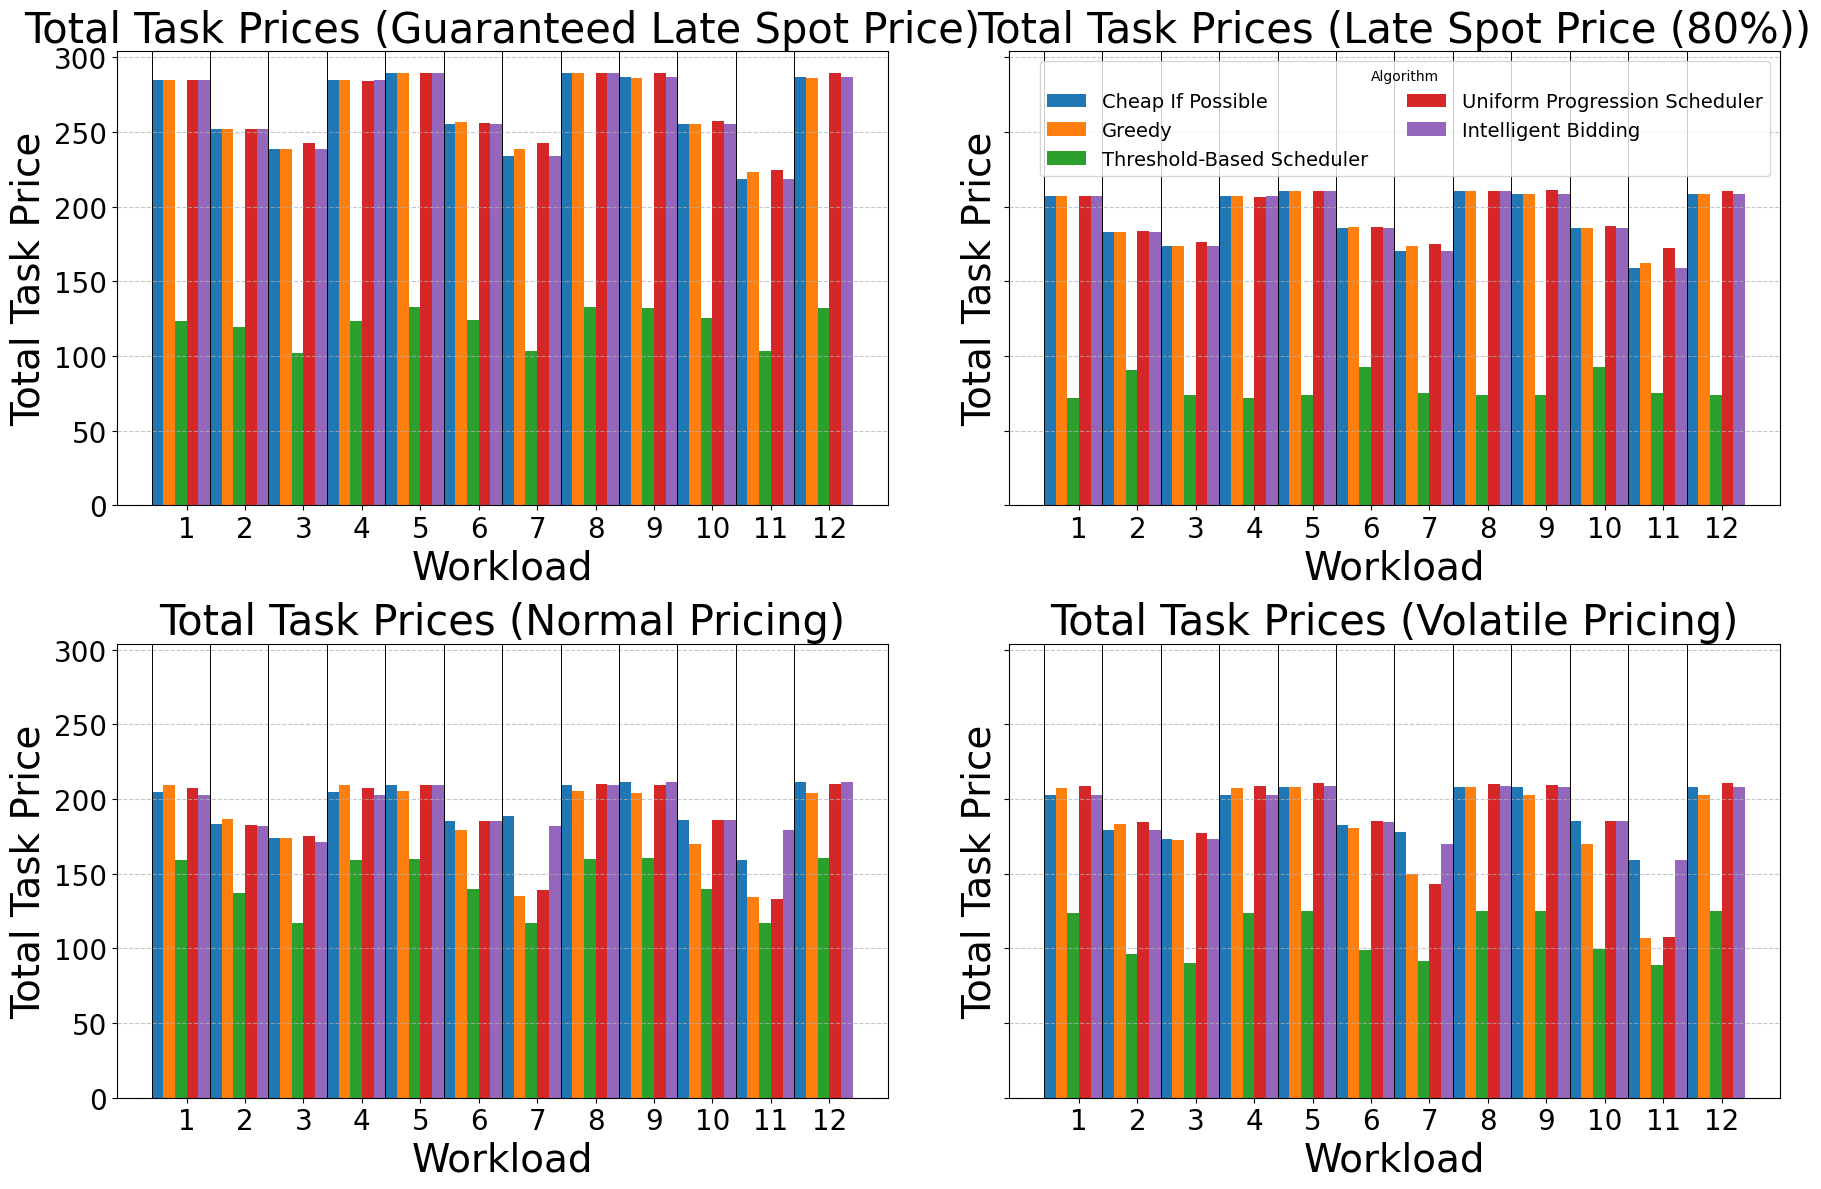

In [29]:
bar_width = 0.2
x_positions = range(12) # 12 workloads for each algorithm
num_algorithms = len(results) # number of algorithms


fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)
axes = axes.flatten()  # flatten for easier iteration



for idx, ax in enumerate(axes):
    start = idx * 12
    end = start + 12

    for i, algorithm_results in enumerate(results):
        prices_subset = algorithm_results["Total_Prices"][start:end]  # subset of prices
        ax.bar(
            [x + i * bar_width for x in x_positions], 
            prices_subset, 
            width=bar_width, 
            label=algorithm_results["Algorithm"]
        )

    # vertical lines shifted half a column space to the left. annoying but this now aligns with the workloads
    for x in x_positions:
        ax.axvline(x - bar_width / 2, color='black', linestyle='-', linewidth=0.7)

    ax.set_title(f"Total Task Prices ({sections[idx]})", fontsize=30)
    ax.set_xlabel("Workload", fontsize=28)
    ax.set_ylabel("Total Task Price", fontsize=28)

    
    ax.grid(axis='x', visible=False)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    ax.tick_params(axis='y', labelsize=20)
    ax.set_xticks([x + (num_algorithms * bar_width / 2) for x in x_positions])
    ax.set_xticklabels(range(1, 13), fontsize=20)


# legend in top right subplot (axes[1])
axes[1].legend(title="Algorithm", loc="upper right", fontsize=14, ncol=2)
plt.tight_layout()
plt.show()
